In [3]:
import pandas as pd
import re
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils import class_weight
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification, create_optimizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- ধাপ ১: ডেটা লোডিং ও ক্লিনিং ---

df = pd.read_csv("/content/drive/MyDrive/BenglaDataset14k.csv")
df = df.dropna().drop_duplicates(subset=['text'])

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)             # URL
    text = re.sub(r"<.*?>", "", text)                # HTML tags
    text = re.sub(r"[^ঀ-৿a-zA-Z0-9\s]", " ", text) # বাংলা/ইংরেজি ছাড়া বাদ
    text = re.sub(r"\s+", " ", text).strip()       # অতিরিক্ত স্পেস
    return text

df['text'] = df['text'].apply(clean_text)
df['label'] = df['label'].astype(int)

print(f"ডেটা ক্লিনিং সম্পন্ন। মোট ডেটা: {len(df)}")
print(f"অরিজিনাল ডেটা ডিস্ট্রিবিউশন:\n{df['label'].value_counts(normalize=True)}")

# --- ধাপ ২: ডেটা বিভাজন (Train/Test Split) ---

X = df['text']
y = df['label']

train_texts, test_texts, train_labels, test_labels = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nট্রেনিং সেট সাইজ: {len(train_texts)}")
print(f"টেস্ট সেট সাইজ: {len(test_texts)}")

# --- ধাপ ৩: RoBERTa টোকেনাইজেশন ---

# *** শুধু এই লাইনটি পরিবর্তন করা হয়েছে ***
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

# --- ধাপ ৪: TF Dataset তৈরি ---

train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    train_labels.values
)).shuffle(1000).batch(16)

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    test_labels.values
)).batch(16)


# --- ধাপ ৫: Class Weight গণনা ---

weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(weights))

print(f"\nClass Weights গণনা করা হয়েছে: {class_weight_dict}")

# --- ধাপ ৬: মডেল লোডিং ও কম্পাইল ---

# *** শুধু এই লাইনটি পরিবর্তন করা হয়েছে ***
model = TFAutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    use_safetensors=False
)

# অপটিমাইজার
batch_size = 16
epochs = 5
num_train_steps = (len(train_texts) // batch_size) * epochs
num_warmup_steps = int(0.1 * num_train_steps)

optimizer, lr_schedule = create_optimizer(
    init_lr=2e-5,
    num_train_steps=num_train_steps,
    num_warmup_steps=num_warmup_steps,
    weight_decay_rate=0.01
)

loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

# কলব্যাক
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, verbose=1)


# --- ধাপ ৭: মডেল ট্রেনিং (class_weight সহ) ---

print("\n--- RoBERTa মডেল ট্রেনিং শুরু ---")



ডেটা ক্লিনিং সম্পন্ন। মোট ডেটা: 13951
অরিজিনাল ডেটা ডিস্ট্রিবিউশন:
label
0    0.501756
1    0.498244
Name: proportion, dtype: float64

ট্রেনিং সেট সাইজ: 11160
টেস্ট সেট সাইজ: 2791


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]


Class Weights গণনা করা হয়েছে: {0: np.float64(0.9964285714285714), 1: np.float64(1.0035971223021583)}


tf_model.h5:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All model checkpoint layers were used when initializing TFXLMRobertaForSequenceClassification.

Some layers of TFXLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- RoBERTa মডেল ট্রেনিং শুরু ---


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
history = model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=test_dataset,

    class_weight=class_weight_dict
)

print("\n--- ট্রেনিং সম্পন্ন ---")

# --- ধাপ ৮: মূল্যায়ন ---

print("\n--- ফাইনাল মডেল মূল্যায়ন (টেস্ট সেটে) ---")
loss, accuracy = model.evaluate(test_dataset)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# ক্লাসিফিকেশন রিপোর্ট
y_pred_probs = model.predict(test_dataset)['logits']
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(test_labels, y_pred_classes, target_names=[str(c) for c in np.unique(y)]))

Epoch 1/5
698/698 [==============================] - 443s 595ms/step - loss: 0.2972 - accuracy: 0.8384 - val_loss: 0.1194 - val_accuracy: 0.9570
Epoch 2/5
698/698 [==============================] - 416s 596ms/step - loss: 0.0796 - accuracy: 0.9708 - val_loss: 0.0835 - val_accuracy: 0.9706
Epoch 3/5
698/698 [==============================] - 416s 596ms/step - loss: 0.0363 - accuracy: 0.9881 - val_loss: 0.0961 - val_accuracy: 0.9756
Epoch 4/5
698/698 [==============================] - 416s 596ms/step - loss: 0.0215 - accuracy: 0.9935 - val_loss: 0.0727 - val_accuracy: 0.9799
Epoch 5/5
698/698 [==============================] - 416s 595ms/step - loss: 0.0092 - accuracy: 0.9978 - val_loss: 0.0810 - val_accuracy: 0.9803

--- ট্রেনিং সম্পন্ন ---

--- ফাইনাল মডেল মূল্যায়ন (টেস্ট সেটে) ---
175/175 [==============================] - 26s 149ms/step - loss: 0.0810 - accuracy: 0.9803
Test Loss: 0.0810
Test Accuracy: 0.9803
175/175 [==============================] - 28s 146ms/step

Classification R

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


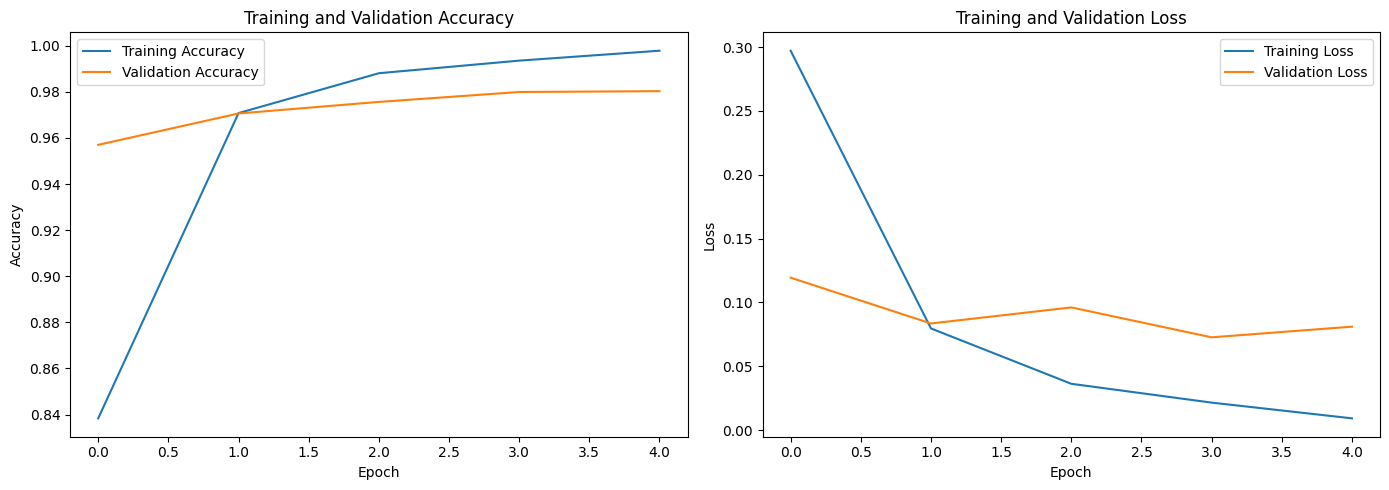

In [5]:
import matplotlib.pyplot as plt

# --- নিশ্চিত করুন যে আপনার 'history' ভেরিয়েবলটি model.fit() থেকে এসেছে ---
# history = model.fit(...)

print(history.history.keys()) # কী কী মেট্রিক আছে তা দেখার জন্য

# --- Accuracy প্লট করার কোড ---
plt.figure(figsize=(14, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

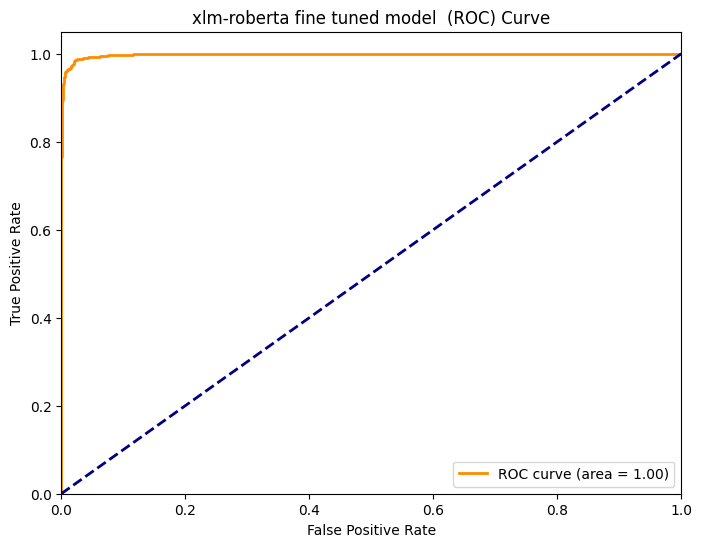

<Figure size 800x600 with 0 Axes>

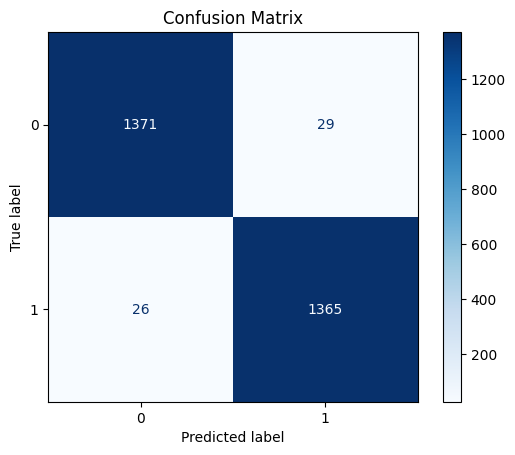

ROC Curve and Confusion Matrix generated successfully.


In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# --- ROC Curve --- (Assuming binary classification and y_pred_probs contains logits)
# Convert logits to probabilities using sigmoid for binary classification
y_pred_probs_softmax = tf.nn.softmax(y_pred_probs, axis=1).numpy()[:, 1]

fpr, tpr, thresholds = roc_curve(test_labels, y_pred_probs_softmax)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('xlm-roberta fine tuned model  (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# --- Confusion Matrix ---
cm = confusion_matrix(test_labels, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

print("ROC Curve and Confusion Matrix generated successfully.")